In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the IRIS DATASET from seaborn/Scikit learn 
df = sns.load_dataset('iris')

df.head(150)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [6]:
df.keys()

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

<Figure size 100x800 with 0 Axes>

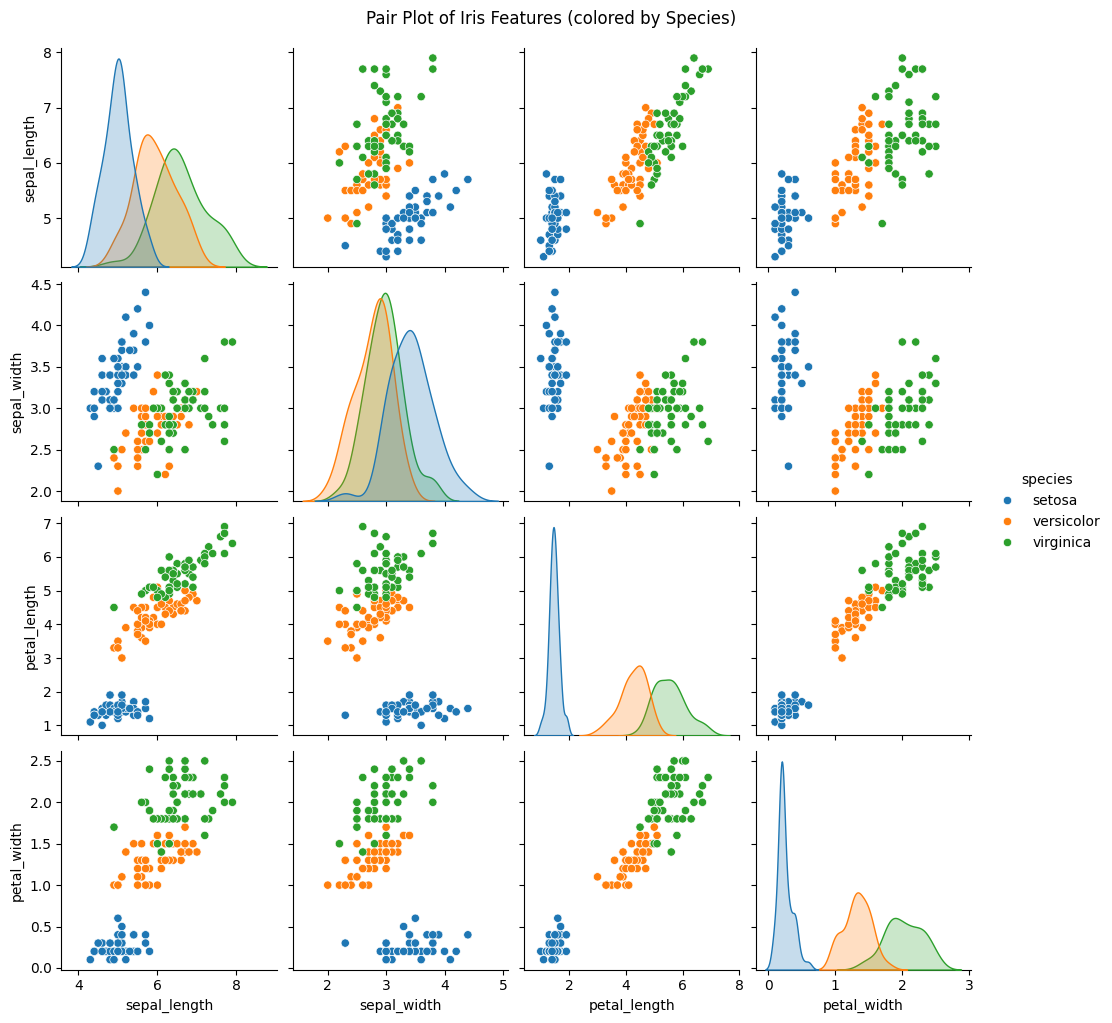

In [8]:
# Pairplot (Multivariate Visualization)
plt.figure(figsize=(1,8))
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle("Pair Plot of Iris Features (colored by Species)", y=1.02)
plt.show()

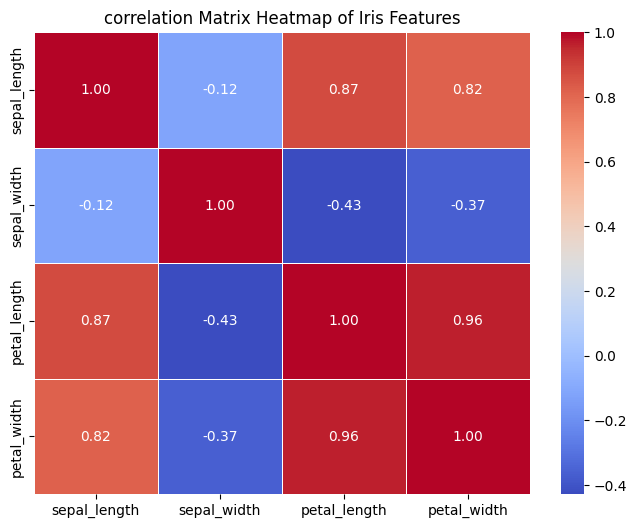

In [10]:
# Heatmaps (Correlation matrix)
# calculate correlation matrix
correlation_matrix = df.drop('species', axis=1).corr()

# Plotting the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot=True,  #this will show the correlation values on the mapa
    cmap='coolwarm',  #This is Colormap
    fmt=".2f",   # Format Numbers to two decimal Places
    linewidths=.5,  ##Lines between cells
    cbar=True       #Show the color bar
)

plt.title('correlation Matrix Heatmap of Iris Features')
plt.show()

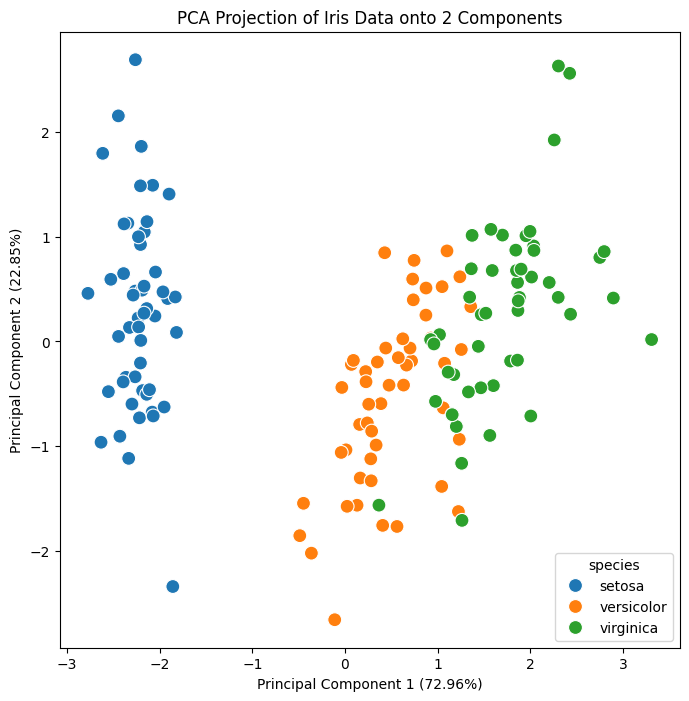

In [16]:
# Dimentionality reduction (PCA)?
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Separate features and target
features = ['sepal_length', 'sepal_width','petal_length','petal_width']

x= df[features]
y=df['species']

#Standarize the data (PCA is sensitive to scale)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#Apply PCA to reduce to 2 dimension
pca= PCA(n_components=2)
principal_components = pca.fit_transform(x_scaled)

#create a Dataframe for the new components and plots 
pca_df=pd.DataFrame(data=principal_components, columns = ['Principal component 1', 'Principal Component 2'])

pca_df = pd.concat([pca_df,df[['species']]], axis = 1)

# plot the result
plt.figure(figsize = (8,8))
sns.scatterplot(
    data=pca_df,
    x='Principal component 1',
    y='Principal Component 2',
    hue='species',
    s=100
)
plt.title('PCA Projection of Iris Data onto 2 Components')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.show()